In [50]:
import matplotlib.pyplot as plt
import seaborn           as sns

import joblib
import sys
sys.path.append('../../')
doc_path = "../../../densities4risk_doc/Figures/"

import src.fda.kde.estimators           as kde

In [15]:
def add_kde_columns(df):
    import pandas as pd
    import re
    
    out = df.copy()
    
    # ---------------------------
    # 1. Kernel
    # ---------------------------
    out['kernel'] = out['forecast_kde_params'].str.extract(r'^(gaussian|t-student)')
    
    # ---------------------------
    # 2. Bandwidth method
    # ---------------------------
    def extract_bandwidth(text):
        if 'cross_validate' in text:
            return 'cross-validation'
        elif 'adaptive' in text:
            return 'adaptive'
        elif 'rot_robust' in text:
            return 'rot (robust)'
        elif 'rot' in text:
            return 'rot'
        else:
            return 'unknown'
    
    out['bandwidth'] = out['forecast_kde_params'].apply(extract_bandwidth)
    
    # ---------------------------
    # 3. Rolling window (numeric)
    # ---------------------------
    out['rolling_window'] = (
        out['forecast_pp_params']
        .str.extract(r'rolling_w(\d+)')
        .astype(str)  # allows NaN if expanding
    )
    
    # Optional: cleaner label
    out['rolling_window_label'] = out['rolling_window'].apply(
        lambda x: f"{int(x)} days" if pd.notnull(x) else 'expanding'
    )
    
    return out

In [16]:
df_cv = joblib.load('../../data/processed/cv_divergences_long_20260316.jbl')
df_cv["forecast_kde_pp_params"] = df_cv["forecast_kde_params"] + "___" + df_cv["forecast_pp_params"]
df_cv = add_kde_columns(df_cv)

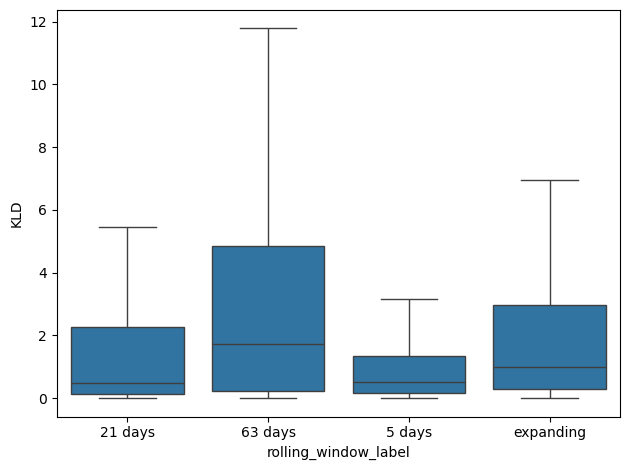

In [49]:
# Metric to plot
metric = 'KLD'

# Re-generate the 3 stacked boxplots

sns.boxplot(x='rolling_window_label', y=metric, data=df_cv, showfliers=False)

fig.suptitle(f'Boxplot of {metric} by Rolling Window')

plt.tight_layout()

plt.savefig(f"{doc_path}boxplot_window.png")